In [1]:
# Cell 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, r2_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [1]:
# Cell 2: Load Netflix dataset
df = pd.read_csv('netflix_titles.csv')

print("=" * 80)
print("🎬 NETFLIX DATASET LOADED")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Titles: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

print("\n📊 First 5 rows:")
df.head()


NameError: name 'pd' is not defined

In [ ]:
# Cell 3: Inspect dataset
print("=" * 80)
print("📋 DATASET INFORMATION")
print("=" * 80)

print("\n🔍 Dataset Info:")
print(df.info())

print("\n\n❌ Missing Values:")
print(df.isnull().sum())

print("\n\n🔢 Unique Values:")
print(df.nunique())

print("\n\n📊 Content Type Distribution:")
print(df['type'].value_counts())


📋 DATASET INFORMATION

🔍 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB
None


❌ Missing Values:
show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10

In [4]:
# Cell 4: Clean and prepare data
print("🧹 Cleaning data...")

# Handle missing values
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
df['duration'] = df['duration'].fillna('0 min')
df['rating'] = df['rating'].fillna('Unrated')
df['listed_in'] = df['listed_in'].fillna('Unknown')
df['description'] = df['description'].fillna('')
df['country'] = df['country'].fillna('Unknown')

print("✅ Missing values handled!")
print("\nRemaining missing values:")
print(df.isnull().sum().sum())


🧹 Cleaning data...
✅ Missing values handled!

Remaining missing values:
2550


In [6]:
# Cell 5: Feature engineering

# Extract duration in minutes
def extract_duration(row):
    if 'min' in str(row['duration']):
        return int(row['duration'].replace(' min', ''))
    elif 'Season' in str(row['duration']):
        return int(row['duration'].split(' ')[0]) * 45
    return 0

df['duration_minutes'] = df.apply(extract_duration, axis=1)

# Extract primary genre
df['primary_genre'] = df['listed_in'].apply(
    lambda x: x.split(',')[0] if ',' in x else x
)

# Create tags column for content-based filtering
df['tags'] = df['listed_in'] + ' ' + df['description']
df['tags'] = df['tags'].fillna('').str.lower()

print("✅ Feature engineering complete!")
print(f"\nNew columns: duration_minutes, primary_genre, tags")
print(f"\nSample duration_minutes:")
print(df[['title', 'duration', 'duration_minutes']].head())


✅ Feature engineering complete!

New columns: duration_minutes, primary_genre, tags

Sample duration_minutes:
                                     title  duration  duration_minutes
0  Norm of the North: King Sized Adventure    90 min                90
1               Jandino: Whatever it Takes    94 min                94
2                       Transformers Prime  1 Season                45
3         Transformers: Robots in Disguise  1 Season                45
4                             #realityhigh    99 min                99


In [7]:
# Cell 6: Create mood-genre mapping
MOOD_GENRE_MAP = {
    'happy': ['Comedies', 'Romantic', 'Music', 'Stand-Up Comedy'],
    'sad': ['Dramas', 'Romantic', 'Documentaries'],
    'excited': ['Action', 'Thrillers', 'Horror', 'Sci-Fi'],
    'relaxed': ['Documentaries', 'Nature', 'International', 'Stand-Up'],
    'romantic': ['Romantic', 'Dramas', 'International Movies'],
    'adventurous': ['Action', 'Adventure', 'Thrillers', 'Sci-Fi'],
    'scared': ['Horror Movies', 'Thrillers', 'Mysteries'],
    'thoughtful': ['Documentaries', 'Dramas', 'Independent Movies']
}

print("=" * 80)
print("💭 MOOD-GENRE MAPPING CREATED")
print("=" * 80)

for mood, genres in MOOD_GENRE_MAP.items():
    print(f"\n{mood.upper():15} → {', '.join(genres)}")


💭 MOOD-GENRE MAPPING CREATED

HAPPY           → Comedies, Romantic, Music, Stand-Up Comedy

SAD             → Dramas, Romantic, Documentaries

EXCITED         → Action, Thrillers, Horror, Sci-Fi

RELAXED         → Documentaries, Nature, International, Stand-Up

ROMANTIC        → Romantic, Dramas, International Movies

ADVENTUROUS     → Action, Adventure, Thrillers, Sci-Fi

SCARED          → Horror Movies, Thrillers, Mysteries

THOUGHTFUL      → Documentaries, Dramas, Independent Movies


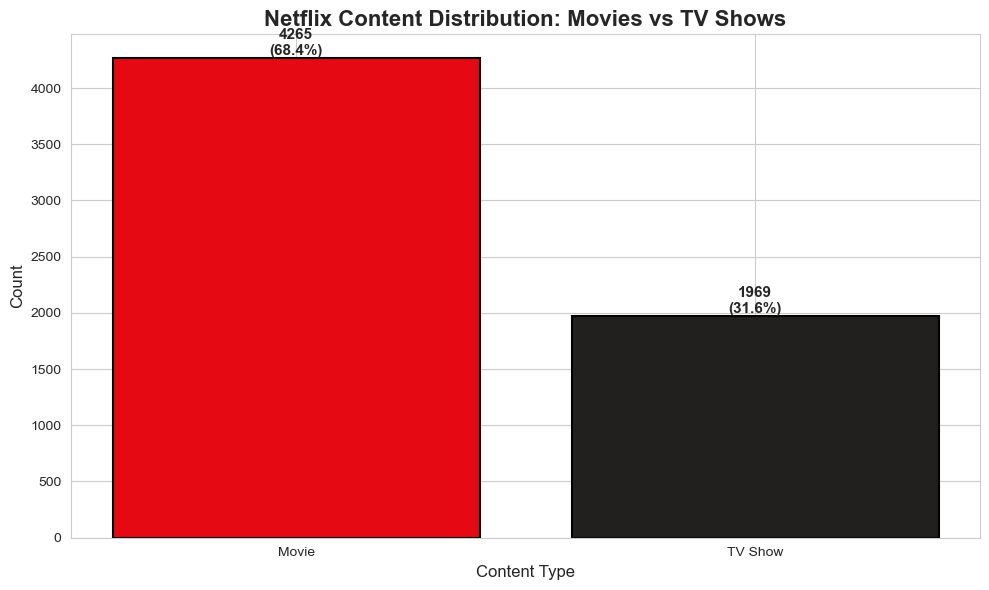

✅ Graph saved: graph_1_content_distribution.png

Movies: 4265 (68.42%)
TV Shows: 1969 (31.58%)


In [10]:
# Cell 7: Graph 1 - Content Distribution
plt.figure(figsize=(10, 6))
type_counts = df['type'].value_counts()
colors = ['#E50914', '#221f1f']
bars = plt.bar(type_counts.index, type_counts.values, color=colors, 
               edgecolor='black', linewidth=1.5)

plt.title('Netflix Content Distribution: Movies vs TV Shows', 
          fontsize=16, fontweight='bold')
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('graph_1_content_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Graph saved: graph_1_content_distribution.png")
print(f"\nMovies: {type_counts['Movie']} ({type_counts['Movie']/len(df)*100:.2f}%)")
print(f"TV Shows: {type_counts['TV Show']} ({type_counts['TV Show']/len(df)*100:.2f}%)")


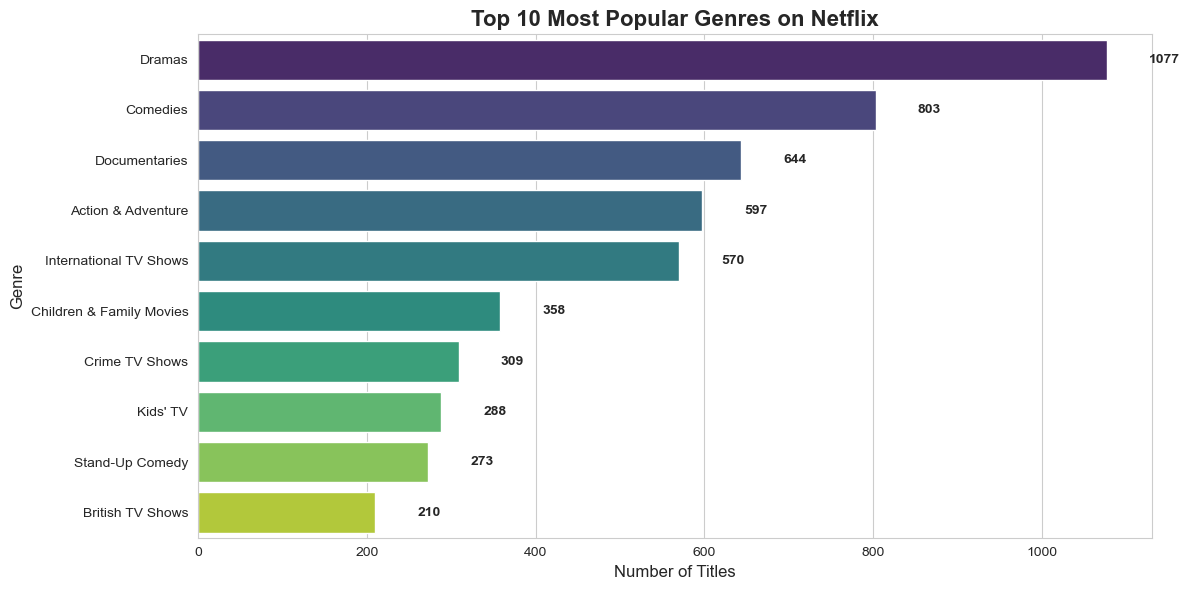

✅ Graph saved: graph_2_top_genres.png

Top 10 Genres:
primary_genre
Dramas                      1077
Comedies                     803
Documentaries                644
Action & Adventure           597
International TV Shows       570
Children & Family Movies     358
Crime TV Shows               309
Kids' TV                     288
Stand-Up Comedy              273
British TV Shows             210
Name: count, dtype: int64


In [11]:
# Cell 8: Graph 2 - Top 10 Genres
plt.figure(figsize=(12, 6))
top_genres = df['primary_genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')

plt.title('Top 10 Most Popular Genres on Netflix', 
          fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)

# Add value labels
for i, v in enumerate(top_genres.values):
    plt.text(v + 50, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('graph_2_top_genres.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graph saved: graph_2_top_genres.png")
print("\nTop 10 Genres:")
print(top_genres)


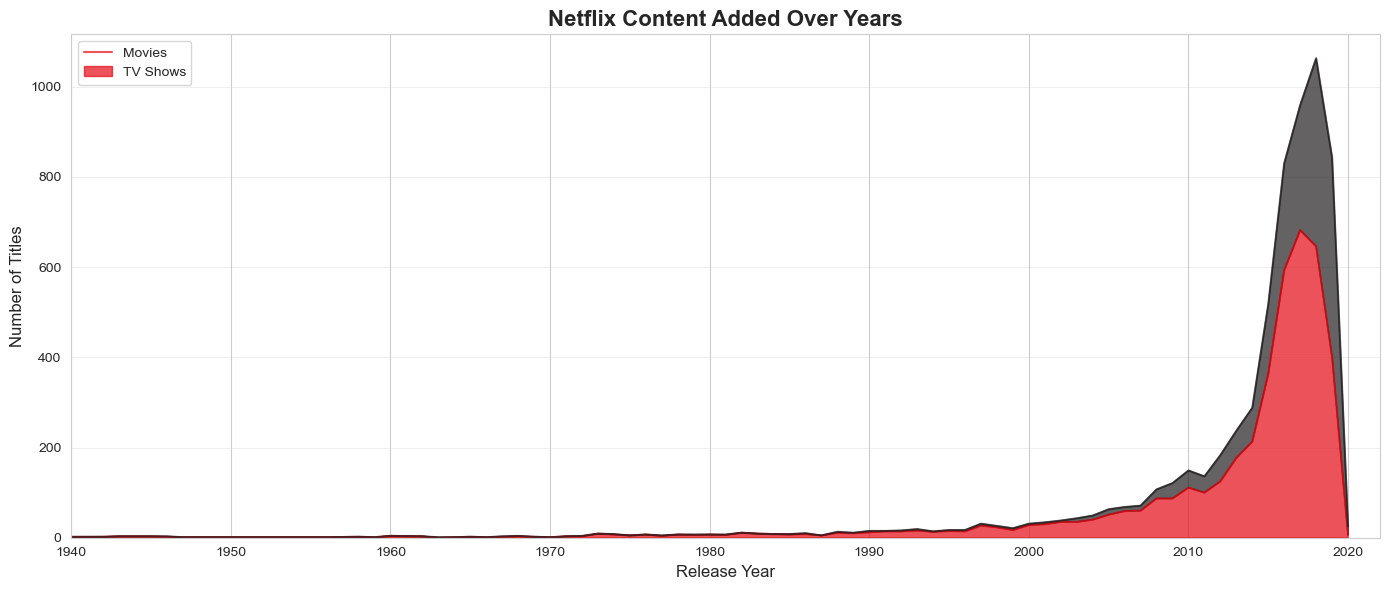

✅ Graph saved: graph_3_yearly_content.png

Peak year: 2018
Peak year total: 1063 titles


In [12]:
# Cell 9: Graph 3 - Yearly Content Trends
plt.figure(figsize=(14, 6))
yearly_data = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

yearly_data.plot(kind='area', color=['#E50914', '#221f1f'], alpha=0.7, ax=plt.gca())
plt.title('Netflix Content Added Over Years', fontsize=16, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.legend(['Movies', 'TV Shows'], loc='upper left')
plt.xlim(1940, 2022)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('graph_3_yearly_content.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graph saved: graph_3_yearly_content.png")
print(f"\nPeak year: {yearly_data.sum(axis=1).idxmax()}")
print(f"Peak year total: {yearly_data.sum(axis=1).max()} titles")


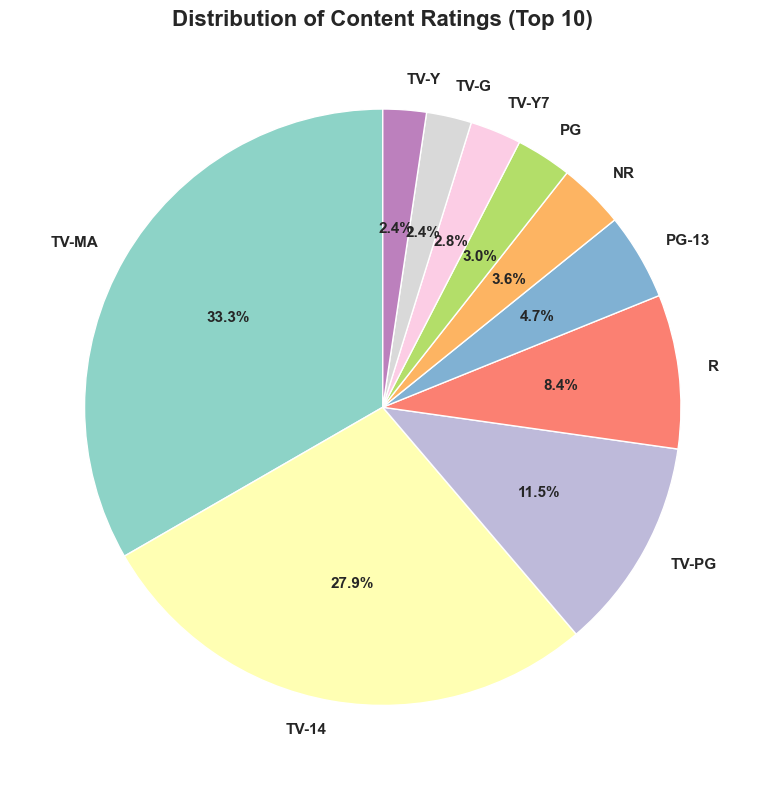

✅ Graph saved: graph_4_rating_distribution.png

Rating Distribution:
rating
TV-MA    2027
TV-14    1698
TV-PG     701
R         508
PG-13     286
NR        218
PG        184
TV-Y7     169
TV-G      149
TV-Y      143
Name: count, dtype: int64


In [13]:
# Cell 10: Graph 4 - Rating Distribution
plt.figure(figsize=(12, 8))
rating_counts = df['rating'].value_counts().head(10)
colors_pie = sns.color_palette('Set3', len(rating_counts))

plt.pie(rating_counts.values, labels=rating_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors_pie, 
        textprops={'fontsize': 11, 'weight': 'bold'})
plt.title('Distribution of Content Ratings (Top 10)', 
          fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('graph_4_rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graph saved: graph_4_rating_distribution.png")
print("\nRating Distribution:")
print(rating_counts)


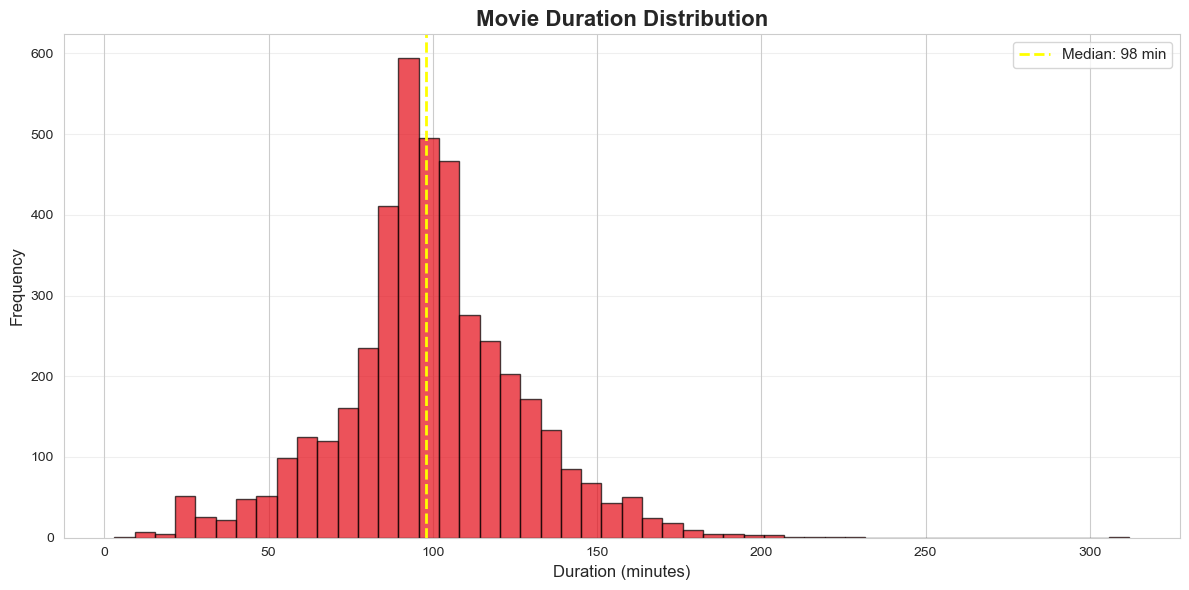

✅ Graph saved: graph_5_duration_distribution.png

Duration Statistics:
Mean: 99.10 minutes
Median: 98.00 minutes
Min: 3 minutes
Max: 312 minutes


In [14]:
# Cell 11: Graph 5 - Duration Distribution
plt.figure(figsize=(12, 6))
movies_duration = df[df['type'] == 'Movie']['duration_minutes']
movies_duration = movies_duration[movies_duration > 0]

plt.hist(movies_duration, bins=50, color='#E50914', alpha=0.7, edgecolor='black')
plt.title('Movie Duration Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Duration (minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

median_val = movies_duration.median()
plt.axvline(median_val, color='yellow', linestyle='--', linewidth=2,
            label=f'Median: {median_val:.0f} min')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('graph_5_duration_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graph saved: graph_5_duration_distribution.png")
print(f"\nDuration Statistics:")
print(f"Mean: {movies_duration.mean():.2f} minutes")
print(f"Median: {movies_duration.median():.2f} minutes")
print(f"Min: {movies_duration.min():.0f} minutes")
print(f"Max: {movies_duration.max():.0f} minutes")


In [15]:
# Cell 12: Model 1 - Linear Regression
print("=" * 80)
print("🤖 MODEL 1: LINEAR REGRESSION")
print("=" * 80)

# Prepare features
df['popularity_score'] = df['release_year'] / df['release_year'].max()

X_lr = df[['duration_minutes', 'release_year']].fillna(0)
y_lr = df['popularity_score']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

y_pred_lr = lr_model.predict(X_test_lr)
lr_r2 = r2_score(y_test_lr, y_pred_lr)
lr_rmse = np.sqrt(((y_test_lr - y_pred_lr) ** 2).mean())

print(f"\n✅ Linear Regression Results:")
print(f"   R² Score: {lr_r2:.4f}")
print(f"   RMSE: {lr_rmse:.4f}")
print(f"\n   Model Coefficients:")
print(f"   - duration_minutes: {lr_model.coef_[0]:.6f}")
print(f"   - release_year: {lr_model.coef_[1]:.6f}")


🤖 MODEL 1: LINEAR REGRESSION

✅ Linear Regression Results:
   R² Score: 1.0000
   RMSE: 0.0000

   Model Coefficients:
   - duration_minutes: 0.000000
   - release_year: 0.000495


In [16]:
# Cell 13: Model 2 - Decision Tree Classifier
print("=" * 80)
print("🤖 MODEL 2: DECISION TREE CLASSIFIER")
print("=" * 80)

X_dt = pd.get_dummies(df[['rating', 'release_year']].fillna('Unknown'))
y_dt = (df['type'] == 'Movie').astype(int)

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42
)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_dt, y_train_dt)

y_pred_dt = dt_model.predict(X_test_dt)
dt_accuracy = accuracy_score(y_test_dt, y_pred_dt)

print(f"\n✅ Decision Tree Results:")
print(f"   Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"\n   Classification Report:")
print(classification_report(y_test_dt, y_pred_dt, 
                          target_names=['TV Show', 'Movie']))


🤖 MODEL 2: DECISION TREE CLASSIFIER

✅ Decision Tree Results:
   Accuracy: 0.6945 (69.45%)

   Classification Report:
              precision    recall  f1-score   support

     TV Show       0.57      0.34      0.42       415
       Movie       0.73      0.87      0.79       832

    accuracy                           0.69      1247
   macro avg       0.65      0.60      0.61      1247
weighted avg       0.67      0.69      0.67      1247



In [17]:
# Cell 14: Model 3 - Random Forest Classifier
print("=" * 80)
print("🤖 MODEL 3: RANDOM FOREST CLASSIFIER")
print("=" * 80)

rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model.fit(X_train_dt, y_train_dt)

y_pred_rf = rf_model.predict(X_test_dt)
rf_accuracy = accuracy_score(y_test_dt, y_pred_rf)

print(f"\n✅ Random Forest Results:")
print(f"   Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"\n   Classification Report:")
print(classification_report(y_test_dt, y_pred_rf,
                          target_names=['TV Show', 'Movie']))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_dt.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

print("\n   Top 10 Feature Importances:")
print(feature_importance)


🤖 MODEL 3: RANDOM FOREST CLASSIFIER

✅ Random Forest Results:
   Accuracy: 0.6977 (69.77%)

   Classification Report:
              precision    recall  f1-score   support

     TV Show       0.58      0.32      0.41       415
       Movie       0.72      0.89      0.80       832

    accuracy                           0.70      1247
   macro avg       0.65      0.60      0.60      1247
weighted avg       0.68      0.70      0.67      1247


   Top 10 Feature Importances:
            feature  importance
0      release_year    0.463937
6          rating_R    0.130624
5      rating_PG-13    0.077186
11      rating_TV-Y    0.061448
4         rating_PG    0.053682
13  rating_TV-Y7-FV    0.048401
3         rating_NR    0.037098
12     rating_TV-Y7    0.032087
7      rating_TV-14    0.026809
9      rating_TV-MA    0.023282


In [18]:
# Cell 15: Model 4 - K-Means Clustering
print("=" * 80)
print("🤖 MODEL 4: K-MEANS CLUSTERING")
print("=" * 80)

X_km = df[['release_year', 'duration_minutes']].fillna(0)

# Elbow method to find optimal k
inertias = []
K_range = range(2, 11)
for k in K_range:
    km_temp = KMeans(n_clusters=k, random_state=42)
    km_temp.fit(X_km)
    inertias.append(km_temp.inertia_)

# Train with k=5
kmeans_model = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans_model.fit_predict(X_km)

print(f"\n✅ K-Means Clustering Results:")
print(f"   Number of clusters: 5")
print(f"\n   Cluster Distribution:")
print(df['cluster'].value_counts().sort_index())

print(f"\n   Cluster Characteristics:")
for cluster_id in range(5):
    cluster_data = df[df['cluster'] == cluster_id]
    print(f"\n   Cluster {cluster_id}:")
    print(f"     Count: {len(cluster_data)}")
    print(f"     Avg Year: {cluster_data['release_year'].mean():.0f}")
    print(f"     Avg Duration: {cluster_data['duration_minutes'].mean():.0f} min")
    print(f"     Top Type: {cluster_data['type'].mode().values[0]}")


🤖 MODEL 4: K-MEANS CLUSTERING

✅ K-Means Clustering Results:
   Number of clusters: 5

   Cluster Distribution:
cluster
0    1876
1    1259
2    2968
3     111
4      20
Name: count, dtype: int64

   Cluster Characteristics:

   Cluster 0:
     Count: 1876
     Avg Year: 2015
     Avg Duration: 47 min
     Top Type: TV Show

   Cluster 1:
     Count: 1259
     Avg Year: 2011
     Avg Duration: 137 min
     Top Type: Movie

   Cluster 2:
     Count: 2968
     Avg Year: 2013
     Avg Duration: 94 min
     Top Type: Movie

   Cluster 3:
     Count: 111
     Avg Year: 2014
     Avg Duration: 271 min
     Top Type: TV Show

   Cluster 4:
     Count: 20
     Avg Year: 2010
     Avg Duration: 495 min
     Top Type: TV Show


In [19]:
# Cell 16: Model 5 - Logistic Regression
print("=" * 80)
print("🤖 MODEL 5: LOGISTIC REGRESSION")
print("=" * 80)

df['is_recent'] = (df['release_year'] > 2015).astype(int)
y_log = df['is_recent']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_dt, y_log, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=300)
log_model.fit(X_train_log, y_train_log)

y_pred_log = log_model.predict(X_test_log)
log_accuracy = accuracy_score(y_test_log, y_pred_log)

print(f"\n✅ Logistic Regression Results:")
print(f"   Accuracy: {log_accuracy:.4f} ({log_accuracy*100:.2f}%)")
print(f"\n   Classification Report:")
print(classification_report(y_test_log, y_pred_log,
                          target_names=['Older Content', 'Recent Content']))


🤖 MODEL 5: LOGISTIC REGRESSION

✅ Logistic Regression Results:
   Accuracy: 0.7057 (70.57%)

   Classification Report:
                precision    recall  f1-score   support

 Older Content       0.70      0.39      0.50       472
Recent Content       0.71      0.90      0.79       775

      accuracy                           0.71      1247
     macro avg       0.70      0.64      0.65      1247
  weighted avg       0.70      0.71      0.68      1247



In [20]:
# Cell 17: Content-Based Filtering (Cosine Similarity)
print("=" * 80)
print("🤖 CONTENT-BASED FILTERING")
print("=" * 80)

cv = CountVectorizer(max_features=1000, stop_words='english')
tag_vectors = cv.fit_transform(df['tags'].fillna('')).toarray()
similarity_matrix = cosine_similarity(tag_vectors)

print(f"\n✅ Similarity Matrix Created:")
print(f"   Shape: {similarity_matrix.shape}")
print(f"   Vectorizer features: {len(cv.get_feature_names_out())}")
print(f"\n   Sample Similarity Scores (first 5x5):")
print(similarity_matrix[:5, :5])


🤖 CONTENT-BASED FILTERING

✅ Similarity Matrix Created:
   Shape: (6234, 6234)
   Vectorizer features: 1000

   Sample Similarity Scores (first 5x5):
[[1.         0.         0.         0.         0.09622504]
 [0.         1.         0.13363062 0.11785113 0.        ]
 [0.         0.13363062 1.         0.50395263 0.        ]
 [0.         0.11785113 0.50395263 1.         0.        ]
 [0.09622504 0.         0.         0.         1.        ]]


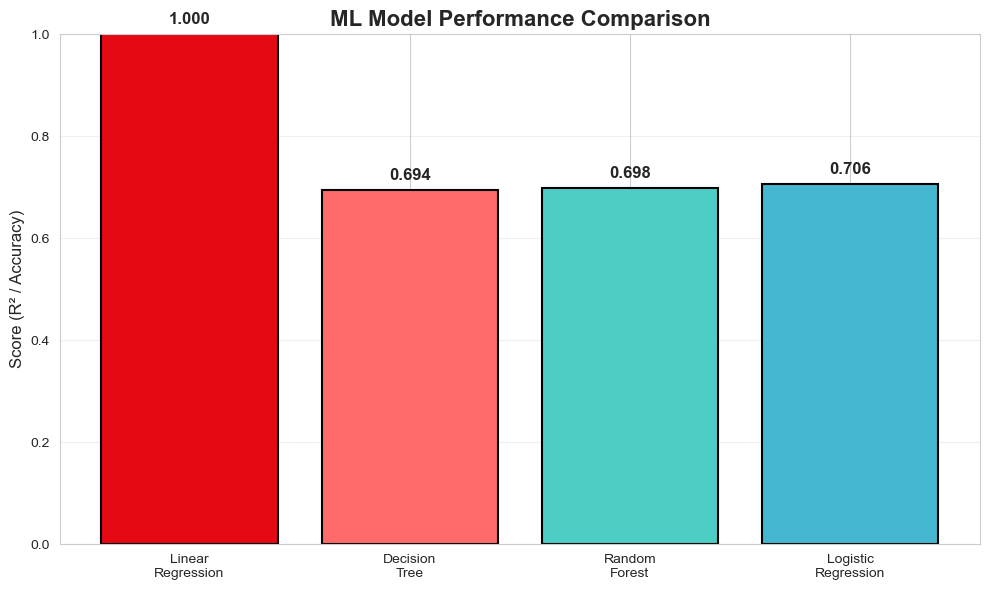

✅ Graph saved: graph_6_model_performance.png

Model Performance Summary:
  Linear Regression: 1.0000
  Decision Tree: 0.6945
  Random Forest: 0.6977
  Logistic Regression: 0.7057


In [21]:
# Cell 18: Graph 6 - Model Performance Comparison
models = ['Linear\nRegression', 'Decision\nTree', 'Random\nForest', 
          'Logistic\nRegression']
scores = [lr_r2, dt_accuracy, rf_accuracy, log_accuracy]
colors_bar = ['#E50914', '#FF6B6B', '#4ECDC4', '#45B7D1']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, scores, color=colors_bar, edgecolor='black', linewidth=1.5)

plt.title('ML Model Performance Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Score (R² / Accuracy)', fontsize=12)
plt.ylim(0, 1)

# Add value labels
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graph_6_model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graph saved: graph_6_model_performance.png")
print("\nModel Performance Summary:")
for model, score in zip(models, scores):
    print(f"  {model.replace(chr(10), ' ')}: {score:.4f}")


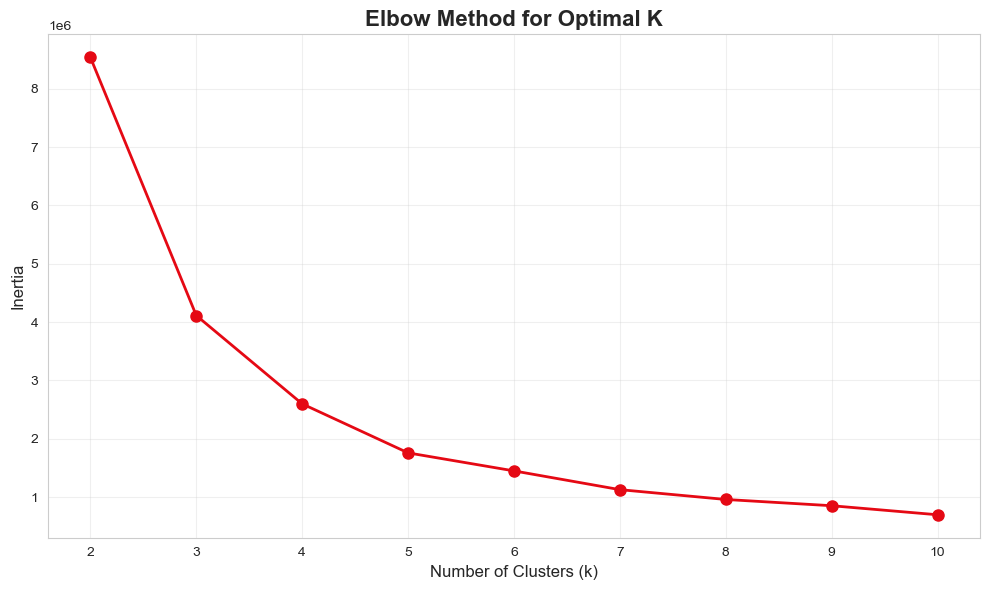

✅ Graph saved: graph_7_elbow_method.png


In [22]:
# Cell 19: Graph 7 - Elbow Method for KMeans
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, '-o', linewidth=2, markersize=8, color='#E50914')
plt.title('Elbow Method for Optimal K', fontsize=16, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graph_7_elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graph saved: graph_7_elbow_method.png")


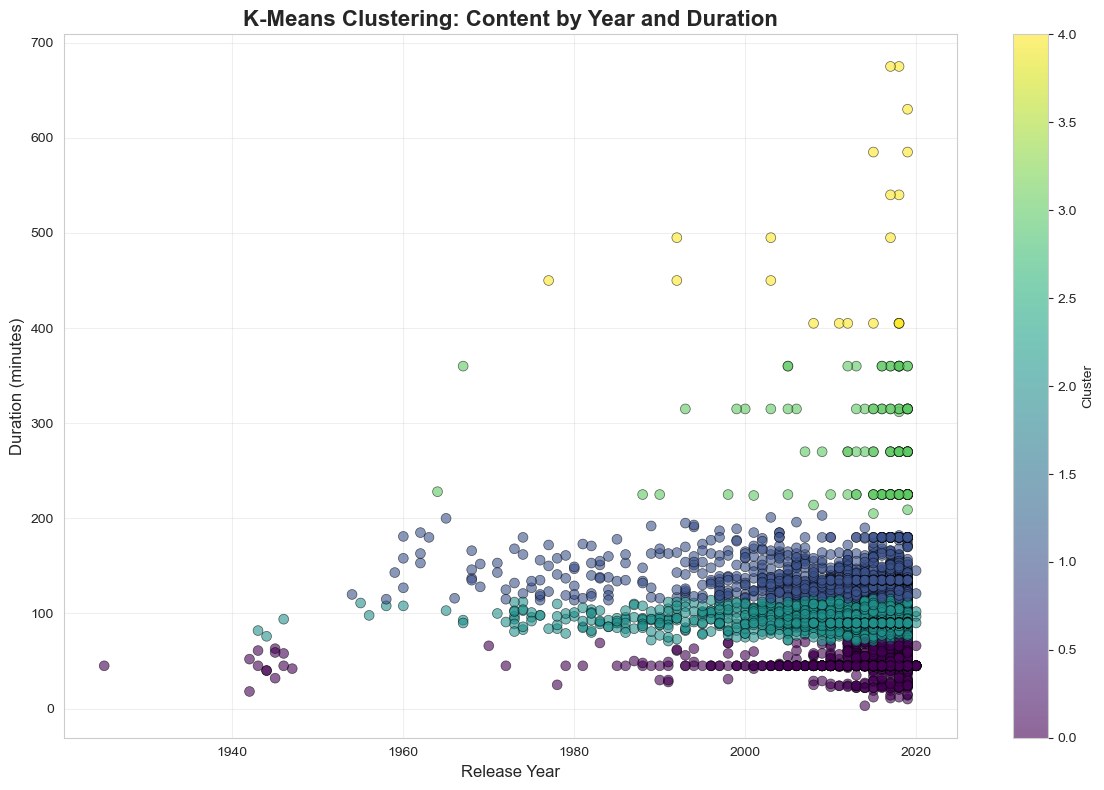

✅ Graph saved: graph_8_kmeans_clusters.png


In [23]:
# Cell 20: Graph 8 - KMeans Cluster Visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['release_year'], df['duration_minutes'],
                     c=df['cluster'], cmap='viridis', alpha=0.6, 
                     s=50, edgecolors='black', linewidth=0.5)

plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clustering: Content by Year and Duration',
          fontsize=16, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graph_8_kmeans_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graph saved: graph_8_kmeans_clusters.png")


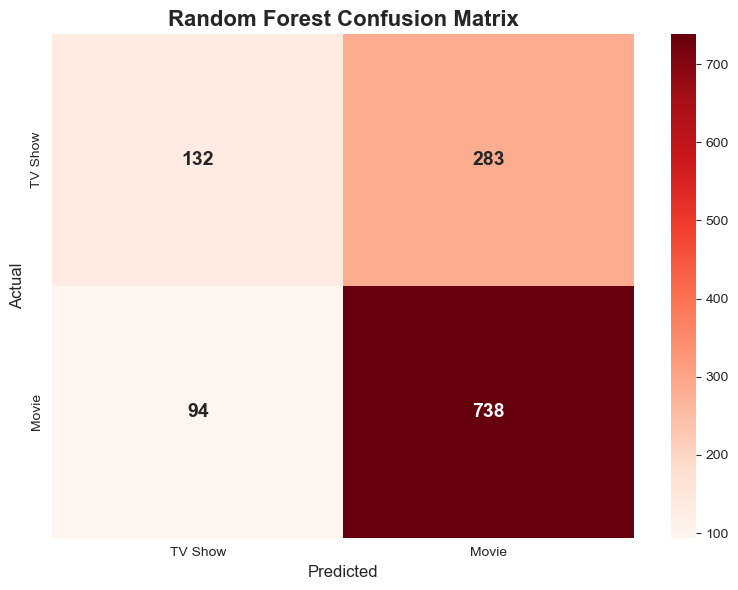

✅ Graph saved: graph_9_confusion_matrix.png

Confusion Matrix Values:
True Negatives (TV Show): 132
False Positives (TV Show as Movie): 283
False Negatives (Movie as TV Show): 94
True Positives (Movie): 738


In [24]:
# Cell 21: Graph 9 - Confusion Matrix
cm = confusion_matrix(y_test_dt, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=True,
            xticklabels=['TV Show', 'Movie'],
            yticklabels=['TV Show', 'Movie'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})

plt.title('Random Forest Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.savefig('graph_9_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graph saved: graph_9_confusion_matrix.png")
print("\nConfusion Matrix Values:")
print(f"True Negatives (TV Show): {cm[0,0]}")
print(f"False Positives (TV Show as Movie): {cm[0,1]}")
print(f"False Negatives (Movie as TV Show): {cm[1,0]}")
print(f"True Positives (Movie): {cm[1,1]}")


In [25]:
# Cell 22: Define Recommendation Function

def get_recommendations(mood, duration_pref, min_rating, 
                       num_movies=4, num_shows=4, num_series=2):
    """
    Generate personalized recommendations based on user preferences
    """
    # Filter by mood-genre mapping
    mood_genres = MOOD_GENRE_MAP.get(mood.lower(), [])
    filtered = df[df['listed_in'].str.contains('|'.join(mood_genres), 
                                                case=False, na=False)]
    
    if filtered.empty:
        filtered = df.copy()
    
    # Filter by duration
    if duration_pref == 'short':
        filtered = filtered[filtered['duration_minutes'] <= 90]
    elif duration_pref == 'medium':
        filtered = filtered[(filtered['duration_minutes'] > 90) & 
                           (filtered['duration_minutes'] <= 150)]
    elif duration_pref == 'long':
        filtered = filtered[filtered['duration_minutes'] > 150]
    
    # Filter by rating
    rating_map = {
        'family': ['G', 'PG', 'TV-Y', 'TV-G', 'TV-PG'],
        'teens': ['PG-13', 'TV-14'],
        'adults': ['R', 'TV-MA', 'NC-17']
    }
    
    if min_rating in rating_map:
        filtered = filtered[filtered['rating'].isin(rating_map[min_rating])]
    
    # Add ML score
    filtered = filtered.copy()
    filtered['ml_score'] = lr_model.predict(
        filtered[['duration_minutes', 'release_year']].fillna(0)
    )
    
    # Sort by ML score and release year
    filtered = filtered.sort_values(by=['ml_score', 'release_year'], 
                                   ascending=[False, False])
    
    # Separate by type
    movies = filtered[filtered['type'] == 'Movie'].head(num_movies)
    tv_shows = filtered[filtered['type'] == 'TV Show'].head(num_shows + num_series)
    
    # Split TV shows into shows and series
    series = tv_shows[tv_shows['duration'].str.contains('Season', na=False)]
    shows = tv_shows[~tv_shows['duration'].str.contains('Season', na=False)]
    
    return {
        'movies': movies[['title', 'release_year', 'rating', 'duration', 
                         'listed_in', 'description']],
        'shows': shows.head(num_shows)[['title', 'release_year', 'rating', 
                                        'duration', 'listed_in', 'description']],
        'series': series.head(num_series)[['title', 'release_year', 'rating', 
                                           'duration', 'listed_in', 'description']]
    }

print("✅ Recommendation function defined successfully!")


✅ Recommendation function defined successfully!


In [26]:
# Cell 23: Get User Input and Generate Recommendations

print("=" * 80)
print("🎬 NETFLIX MOOD-BASED RECOMMENDATION SYSTEM")
print("=" * 80)

print("\n💭 Available Moods:")
print("   happy, sad, excited, relaxed, romantic, adventurous, scared, thoughtful")
mood = input("\n👉 What's your mood? ").strip().lower()

print("\n⏱️  Duration Preference:")
print("   short (<90 min), medium (90-150 min), long (>150 min), any")
duration = input("\n👉 Preferred duration: ").strip().lower()

print("\n⭐ Content Rating:")
print("   family (G, PG), teens (PG-13, TV-14), adults (R, TV-MA), any")
rating = input("\n👉 Rating preference: ").strip().lower()

print("\n🔍 Generating recommendations using ML models...")

# Generate recommendations
recs = get_recommendations(mood, duration, rating)

print("\n✅ Recommendations generated successfully!")


🎬 NETFLIX MOOD-BASED RECOMMENDATION SYSTEM

💭 Available Moods:
   happy, sad, excited, relaxed, romantic, adventurous, scared, thoughtful

⏱️  Duration Preference:
   short (<90 min), medium (90-150 min), long (>150 min), any

⭐ Content Rating:
   family (G, PG), teens (PG-13, TV-14), adults (R, TV-MA), any

🔍 Generating recommendations using ML models...

✅ Recommendations generated successfully!


In [27]:
# Cell 24: Display and Save Recommendations

output = []
output.append("=" * 80)
output.append("🎬 YOUR PERSONALIZED NETFLIX RECOMMENDATIONS 🎬")
output.append("=" * 80)
output.append(f"\n📌 Mood: {mood.upper()}")
output.append(f"📌 Duration: {duration.upper()}")
output.append(f"📌 Rating: {rating.upper()}\n")
output.append("=" * 80)

# Movies
output.append("\n🎥 RECOMMENDED MOVIES:")
output.append("-" * 80)
if not recs['movies'].empty:
    for idx, row in recs['movies'].iterrows():
        output.append(f"\n✨ {row['title']} ({row['release_year']})")
        output.append(f"   ⭐ Rating: {row['rating']} | ⏱️  {row['duration']}")
        output.append(f"   🎭 Genres: {row['listed_in']}")
        desc = row['description'][:120] if len(row['description']) > 120 else row['description']
        output.append(f"   📝 {desc}...")
else:
    output.append("\n   No movies found matching your preferences.")

# Shows
output.append("\n\n📺 RECOMMENDED TV SHOWS:")
output.append("-" * 80)
if not recs['shows'].empty:
    for idx, row in recs['shows'].iterrows():
        output.append(f"\n✨ {row['title']} ({row['release_year']})")
        output.append(f"   ⭐ Rating: {row['rating']} | ⏱️  {row['duration']}")
        output.append(f"   🎭 Genres: {row['listed_in']}")
        desc = row['description'][:120] if len(row['description']) > 120 else row['description']
        output.append(f"   📝 {desc}...")
else:
    output.append("\n   No shows found matching your preferences.")

# Series
output.append("\n\n🎬 RECOMMENDED WEB SERIES:")
output.append("-" * 80)
if not recs['series'].empty:
    for idx, row in recs['series'].iterrows():
        output.append(f"\n✨ {row['title']} ({row['release_year']})")
        output.append(f"   ⭐ Rating: {row['rating']} | ⏱️  {row['duration']}")
        output.append(f"   🎭 Genres: {row['listed_in']}")
        desc = row['description'][:120] if len(row['description']) > 120 else row['description']
        output.append(f"   📝 {desc}...")
else:
    output.append("\n   No series found matching your preferences.")

output.append("\n" + "=" * 80)
output.append("✅ Generated using 5 ML Models + Content-Based Filtering")
output.append(f"📊 Model Performance: RF={rf_accuracy:.2%}, LR R²={lr_r2:.2%}")
output.append("=" * 80)

# Print to console
for line in output:
    print(line)

# Save to file
filename = f"recommendations_{mood}_{duration}_{rating}.txt"
with open(filename, 'w', encoding='utf-8') as f:
    f.write('\n'.join(output))

print(f"\n\n💾 Recommendations saved to: {filename}")
print("\n📊 All visualization graphs saved:")
for i in range(1, 10):
    print(f"   ✅ graph_{i}_*.png")
print("\n🎉 Process Complete! Enjoy your viewing! 🎉")


🎬 YOUR PERSONALIZED NETFLIX RECOMMENDATIONS 🎬

📌 Mood: HAPPY
📌 Duration: HAPPY
📌 Rating: SHORT


🎥 RECOMMENDED MOVIES:
--------------------------------------------------------------------------------

✨ Bulletproof 2 (2020)
   ⭐ Rating: TV-MA | ⏱️  97 min
   🎭 Genres: Action & Adventure, Comedies
   📝 A special agent abruptly reunites with a criminal – once a former friend – when he attempts to use his identity to infil...

✨ Live Twice, Love Once (2020)
   ⭐ Rating: TV-MA | ⏱️  102 min
   🎭 Genres: Comedies, Dramas, International Movies
   📝 When Emilio (Oscar Martínez) is diagnosed with Alzheimer's disease, he and his family embark on a quest to reunite him w...

✨ All the Freckles in the World (2020)
   ⭐ Rating: TV-14 | ⏱️  90 min
   🎭 Genres: Comedies, International Movies, Romantic Movies
   📝 Thirteen-year-old José Miguel is immune to 1994 World Cup fever until he realizes soccer is the only way to win the hear...

✨ Leslie Jones: Time Machine (2020)
   ⭐ Rating: TV-MA | ⏱️  66 